C:\Users\daniel.m\AppData\Local\Temp\ipykernel_19692\4275458728.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='satisfaction', ax=ax[0], palette='viridis').set_title('Distribución Train')
C:\Users\daniel.m\AppData\Local\Temp\ipykernel_19692\4275458728.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=test_df, x='satisfaction', ax=ax[1], palette='magma').set_title('Distribución Test')


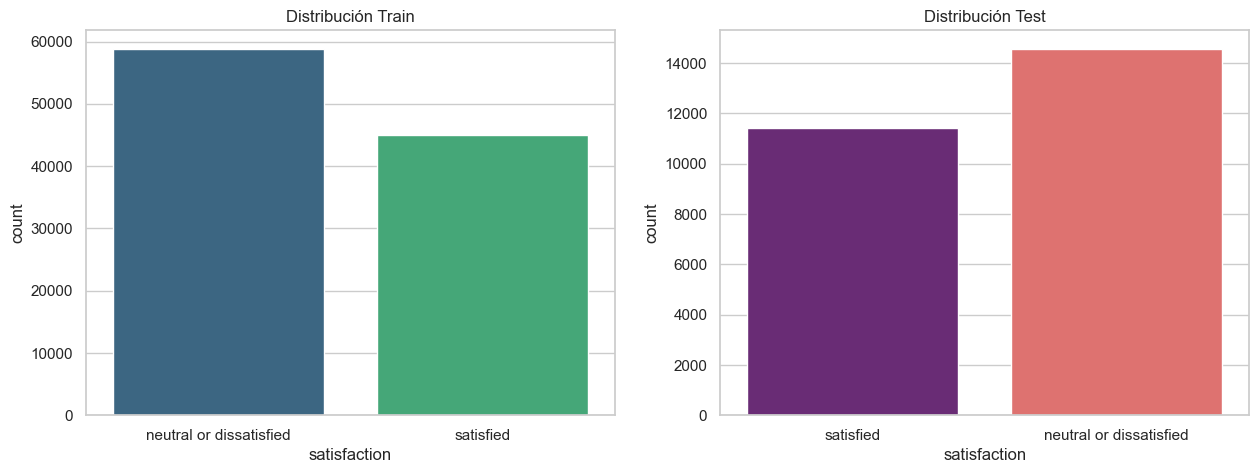

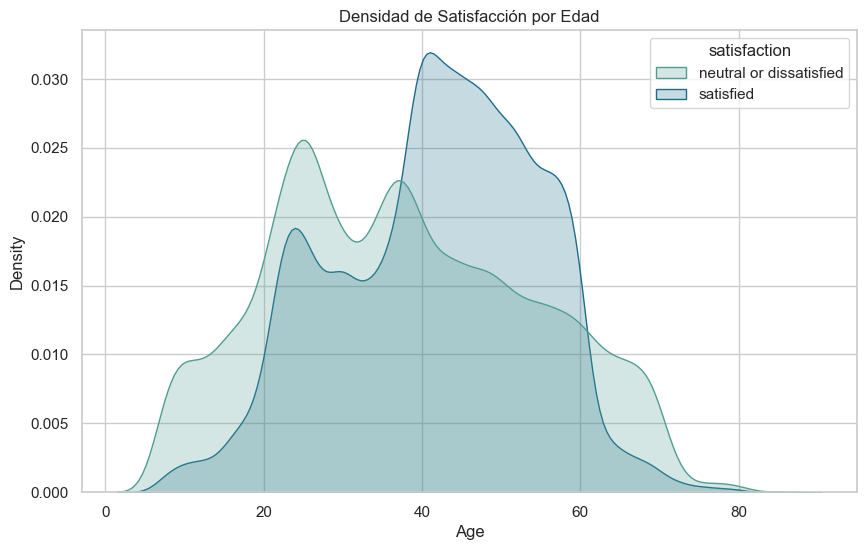

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga simétrica
train_df = pd.read_csv('../data_sample/train.csv').drop(columns=['Unnamed: 0', 'id'], errors='ignore')
test_df = pd.read_csv('../data_sample/test.csv').drop(columns=['Unnamed: 0', 'id'], errors='ignore')

# --- GRÁFICO 1: Comparación Train vs Test ---
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=train_df, x='satisfaction', ax=ax[0], palette='viridis').set_title('Distribución Train')
sns.countplot(data=test_df, x='satisfaction', ax=ax[1], palette='magma').set_title('Distribución Test')
plt.show()

# --- GRÁFICO 2: Relación Edad y Satisfacción ---
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train_df, x="Age", hue="satisfaction", fill=True, common_norm=False, palette='crest')
plt.title('Densidad de Satisfacción por Edad')
plt.show()

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Definimos las columnas
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train_df.select_dtypes(include=['object']).drop(columns=['satisfaction']).columns.tolist()

# Preprocesador profesional
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

# Pipeline con el Modelo
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42))
])

# ENTRENAMIENTO (Solo con train)
X_train = train_df.drop(columns=['satisfaction'])
y_train = train_df['satisfaction']
full_pipeline.fit(X_train, y_train)

C:\Users\daniel.m\AppData\Local\Temp\ipykernel_19692\4166667586.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include=['object']).drop(columns=['satisfaction']).columns.tolist()


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

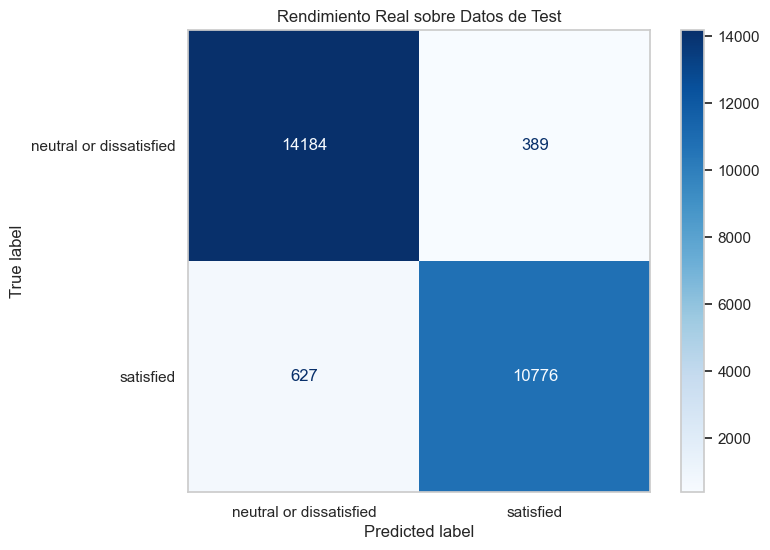

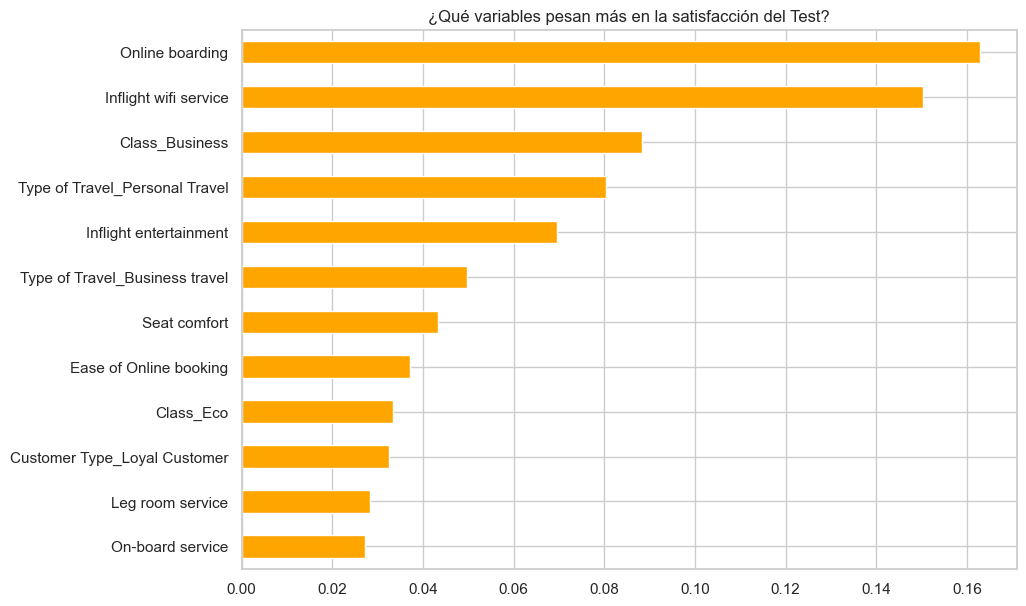

In [5]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# EVALUACIÓN (Sobre el test que el modelo nunca ha visto)
X_test = test_df.drop(columns=['satisfaction'])
y_test = test_df['satisfaction']
y_pred = full_pipeline.predict(X_test)

# --- GRÁFICO 3: Matriz de Confusión sobre el Test ---
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=ax)
plt.title('Rendimiento Real sobre Datos de Test')
plt.grid(False)
plt.show()

# --- GRÁFICO 4: Importancia de Variables ---
importances = full_pipeline.named_steps['model'].feature_importances_
# Recuperar nombres de las columnas transformadas
cat_names = full_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(cat_cols)
all_feat_names = num_cols + list(cat_names)

feat_imp = pd.Series(importances, index=all_feat_names).sort_values(ascending=True).tail(12)
plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh', color='orange')
plt.title('¿Qué variables pesan más en la satisfacción del Test?')
plt.show()

In [8]:
import joblib
import os

# Creamos la ruta completa
output_dir = '../models/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Guardamos el pipeline completo (incluye el preprocesador y el modelo)
model_file = os.path.join(output_dir, 'pipeline_final_aerolinea.joblib')
joblib.dump(full_pipeline, model_file)

print(f"✅ ¡Éxito! El modelo y el preprocesador se han guardado en: {model_file}")

✅ ¡Éxito! El modelo y el preprocesador se han guardado en: ../models/pipeline_final_aerolinea.joblib


In [11]:
modelo_cargado = joblib.load('../models/pipeline_final_aerolinea.joblib')

print("✅ Modelo cargado correctamente y listo para usarse.")

✅ Modelo cargado correctamente y listo para usarse.


In [16]:
# Imaginemos que llega un pasajero nuevo (datos en bruto)
nuevo_pasajero = pd.DataFrame({
    'Gender': ['Female'],
    'Customer Type': ['Loyal Customer'],
    'Age': [35],
    'Type of Travel': ['Business travel'],
    'Class': ['Business'],
    'Flight Distance': [1200],
    'Inflight wifi service': [5],
    'Departure/Arrival time convenient': [4],
    # ... todas las demás columnas que pide el modelo
})

# El modelo ya sabe limpiar y transformar estos datos nuevos gracias al Pipeline
print(f"La predicción para este pasajero es: {prediccion[0]}")

test_df = pd.read_csv('../data_sample/test.csv').drop(columns=['Unnamed: 0', 'id', 'satisfaction'], errors='ignore')

# Cogemos, por ejemplo, la primera fila para probar
pasajero_prueba = test_df.iloc[[0]].copy()

# 3. Si quieres cambiar algo para ver si cambia la predicción, lo haces aquí:
pasajero_prueba['Inflight wifi service'] = 5  # Le ponemos el máximo wifi
pasajero_prueba['Type of Travel'] = 'Business travel'

# 4. ¡Ahora ya no dará error porque están las 25 columnas!
prediccion = modelo_cargado.predict(pasajero_prueba)

print(f"Resultado de la predicción: {prediccion[0]}")

La predicción para este pasajero es: satisfied
Resultado de la predicción: satisfied


In [17]:
# Función para crear un pasajero rápido basado en la estructura real
def crear_pasajero_personalizado(base_df, cambios):
    pasajero = base_df.iloc[[0]].copy()
    for columna, valor in cambios.items():
        pasajero[columna] = valor
    return pasajero

# Ejemplo: Queremos ver qué pasa si un pasajero joven viaja en Business con mal WiFi
mi_caso = crear_pasajero_personalizado(test_df, {
    'Age': 20,
    'Class': 'Business',
    'Inflight wifi service': 1,
    'Seat comfort': 1
})

print(f"Predicción para el caso personalizado: {modelo_cargado.predict(mi_caso)[0]}")

Predicción para el caso personalizado: satisfied
